# Monte Carlo Trails & Active Inference: Zukunfts-Exploration im ewigen Jetzt
### **Autor:** Thomas Riebl (Luxemburg)  
### **Theoretischer Rahmen:** The Conative-Integrative Framework (CIF) & Buch 2 (*Vom Anfang bis zum Ende*)  
### **Themenbereich:** Phasenraum-Trajektorien, Erwartete Freie Energie $G(\pi)$, Softmax-Präzision $\gamma$ & das Specious Present  
### **Datum:** September 2026  

---

## 1. Theoretische Grundlegung: Trails, Phasenraum & das ewige Jetzt

Im **Conative-Integrative Framework (CIF)** und in **Buch 2 (*Vom Anfang bis zum Ende*)** wird die fundamentale Struktur von Zeit, Agency (Handlungsmacht) und Bewusstsein neu fundiert:

1. **Die Begriffsdistinktion: *Trail* vs. *Trial***:
   * **Monte Carlo Trail (Pfad / Trajektorie):** Ein einzelner, probabilistisch explorieter Entwicklungspfad im hochdimensionalen Phasenraum $\tau = (s_0, u_0, s_1, u_1, \dots, s_H)$. Der Trail ist die mikroskopische Zukunfts-Hypothese eines handelnden Agenten.
   * **Monte Carlo Trial (Versuchsdurchlauf / Ensemble-Aggregation):** Ein vollständiger experimenteller oder simulierter Durchlauf, der über eine Schar von $N$ Trails aggregiert, um statistische Erwartungswerte $\mathbb{E}[\Phi(t)]$ und Überlebenswahrscheinlichkeiten $\widehat{P}(\text{Survival})$ zu schätzen.

2. **Das ewige Jetzt und das *Specious Present* (Gegenwartsfenster):**
   * Das Universum existiert physikalisch und ontologisch ausschließlich im **dimensionslosen Jetzt ($t = 0$)**. Weder Vergangenheit noch Zukunft besitzen eine materielle Realität.
   * Dennoch erleben bewusste Systeme ein gefühltes Gegenwartsfenster (*Specious Present*, $\approx 2{-}3$ Sekunden).
   * **Die CIF-Erklärung:** Dieses Gegenwartsfenster ist exakt die **temporale Tiefe $H$ des generativen Modells**. Ein aktives Inferenz-System erzeugt im Jetzt ein kontrafaktisches Bündel von Zukunfts-Pfaden (Monte Carlo Trails), um dissipative Entropie abzuwenden.

3. **Erwartete Freie Energie (Expected Free Energy $G(\pi)$):**
   Für jeden Zukunfts-Trail $\pi = (u_0, u_1, \dots, u_{H-1})$ wird die Erwartete Freie Energie berechnet:
   $$\mathbf{G}(\pi) = \sum_{\tau=1}^H \mathbf{G}(\pi, \tau) \approx \underbrace{\mathbb{E}_{Q}[D_{\text{KL}}(Q(o_\tau|\pi) \parallel P(o_\tau))]}_{\text{Pragmatischer Wert (Diskrepanz zum Ziel)}} + \underbrace{\mathbb{E}_{Q}[H(o_\tau|s_\tau)]}_{\text{Epistemischer Wert (Ambiguität / Rauschen)}}$$

4. **Softmax-Selektion unter Präzision $\gamma$:**
   $$\Large P(\pi) = \sigma(-\gamma G(\pi)) = \frac{\exp(-\gamma G(\pi))}{\sum_{\pi'} \exp(-\gamma G(\pi'))}$$
   * **$\gamma \to 0$ (Exploration / Rauschen):** Gleichverteilung aller Trails.
   * **$\gamma \gg 1$ (Exploitation / Entschlossenheit):** Konzentration auf das strikte Minimum $\pi^* = \arg\min G(\pi)$.

## 2. Simulations-Setup & Konfiguration

Wir initialisieren die Python-Umgebung mit `numpy`, `matplotlib` und `seaborn`. Das Styling entspricht modernem wissenschaftlichen Publishing-Standard.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

# Set seed for deterministic reproducibility
np.random.seed(42)

# Publication-grade styling configuration
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans', 'Arial', 'Helvetica'],
    'axes.edgecolor': '#cbd5e1',
    'axes.linewidth': 1.2,
    'grid.color': '#f1f5f9',
    'grid.linestyle': '--',
    'figure.dpi': 150
})

print("✓ Simulations-Umgebung erfolgreich initialisiert.")


✓ Simulations-Umgebung erfolgreich initialisiert.


## 3. Parameter des Monte-Carlo-Trail-Ensembles

Hier definieren wir die Schlüsselgrößen der Simulation:
* `N_TRAILS`: Anzahl der simultan generierten Pfad-Hypothesen im Jetzt.
* `HORIZON`: Kontrafaktischer Zeithorizont $H$ (Schritte in die Zukunft).
* `START_STATE`: Anfangszustand $s_0$ bei $t = 0$ (gestörter Zustand).
* `TARGET_STATE`: Homöostatischer Sollwert / Attraktor $s^* = 0.0$.
* `NOISE_STD`: Stochastizität der Umwelt / sensorische Fluktuation $\sigma$.
* `GAMMA`: Präzisions-Parameter $\gamma$ (inverse Temperatur) der Handlungsauswahl.

In [2]:
# Hyperparameter-Definition
N_TRAILS     = 60        # Anzahl der Monte-Carlo-Trails (Pfadfinder)
HORIZON      = 25        # Temporale Tiefe H (kontrafaktische Inferenz-Schritte)
TARGET_STATE = 0.0       # Homöostatischer Attraktor s*
START_STATE  = 3.5       # Gestörter Ausgangszustand s0 bei t=0
NOISE_STD    = 0.35      # Umweltstochastizität (Gaussian Noise)
GAMMA        = 2.5       # Präzision gamma (Inverse Temperatur)

print(f"Hyperparameter festgelegt:")
print(f"  • Trails N           : {N_TRAILS}")
print(f"  • Zeithorizont H     : {HORIZON}")
print(f"  • Zustand s0 -> s*   : {START_STATE} -> {TARGET_STATE}")
print(f"  • Umweltrauschen σ   : {NOISE_STD}")
print(f"  • Präzision γ        : {GAMMA}")


Hyperparameter festgelegt:
  • Trails N           : 60
  • Zeithorizont H     : 25
  • Zustand s0 -> s*   : 3.5 -> 0.0
  • Umweltrauschen σ   : 0.35
  • Präzision γ        : 2.5


## 4. Simulation Engine: Generierung der Phasenraum-Trails

In jedem Zeitschritt berechnet der Agent eine Handlungsintention in Richtung des homöostatischen Attraktors. Diese wird durch umweltbedingtes Rauschen perturbiert. Für jeden Trail wird die Erwartete Freie Energie als kumulierte quadratische Abweichung vom Sollwert aggregiert.

In [3]:
# Datenstrukturen für Trails und Kosten
trails = np.zeros((N_TRAILS, HORIZON))
free_energies = np.zeros(N_TRAILS)
control_intents = np.zeros(N_TRAILS)

for i in range(N_TRAILS):
    state = START_STATE
    trail_states = [state]
    trail_cost = 0.0
    
    # Jede Policy sampelt eine individuelle Steuerungsintensität
    intent = np.random.uniform(0.10, 0.45)
    control_intents[i] = intent
    
    for t in range(1, HORIZON):
        # Aktionskraft: Negativer Gradient zum Attraktor
        action = -intent * (state - TARGET_STATE)
        
        # Sensorisch-thermodynamisches Rauschen
        noise = np.random.normal(0, NOISE_STD)
        
        # Zustandsübergang: s_{t+1} = s_t + action + noise
        state = state + action + noise
        trail_states.append(state)
        
        # Akkumulierte quadratische Abweichung (Expected Free Energy proxy)
        trail_cost += (state - TARGET_STATE)**2
        
    trails[i, :] = trail_states
    free_energies[i] = trail_cost

# Softmax-Gewichtung: P(pi) ~ exp(-gamma * G_norm)
norm_g = (free_energies - np.min(free_energies)) / (np.max(free_energies) - np.min(free_energies) + 1e-8)
weights = np.exp(-GAMMA * norm_g)
weights /= np.sum(weights)

# Identifikation des optimalen Trails pi*
best_trail_idx = np.argmin(free_energies)
best_trail = trails[best_trail_idx, :]

print(f"✓ Simulation abgeschlossen: {N_TRAILS} Trails generiert.")
print(f"  • Minimales G(π*)    : {free_energies[best_trail_idx]:.3f} (Trail #{best_trail_idx})")
print(f"  • Maximales G        : {np.max(free_energies):.3f}")
print(f"  • Mittleres G        : {np.mean(free_energies):.3f} ± {np.std(free_energies):.3f}")
print(f"  • Max P(π*)          : {weights[best_trail_idx]*100:.2f} % Auswahlwahrscheinlichkeit")


✓ Simulation abgeschlossen: 60 Trails generiert.
  • Minimales G(π*)    : 8.756 (Trail #41)
  • Maximales G        : 94.312
  • Mittleres G        : 27.846 ± 19.316
  • Max P(π*)          : 2.58 % Auswahlwahrscheinlichkeit


## 5. Dreiteilige Publikations-Visualisierung

Wir visualisieren das Trail-Ensemble in drei synchronisierten Panels:
1. **Panel A (Links):** Das Phasenraum-Bündel der Monte-Carlo-Trails im Specious Present ($t = 0$), inklusive des 68%-Konfidenzbandes und des selektierten Sieger-Trails $\pi^*$.
2. **Panel B (Rechts Oben):** Verteilung der Erwarteten Freien Energie $G(\pi)$ mit Kernel-Density-Estimation (KDE).
3. **Panel C (Rechts Unten):** Softmax-Selektionswahrscheinlichkeiten $P(\pi)$ für die Top-15 Pfad-Kandidaten.

✓ Abbildung erfolgreich gespeichert:
  • /home/thr/Documents/active-inference-phi-network/images/monte_carlo_trails_simulation.png
  • /home/thr/Documents/ThRNotes/Alle_Braindumps_PDF/monte_carlo_trails_simulation.png


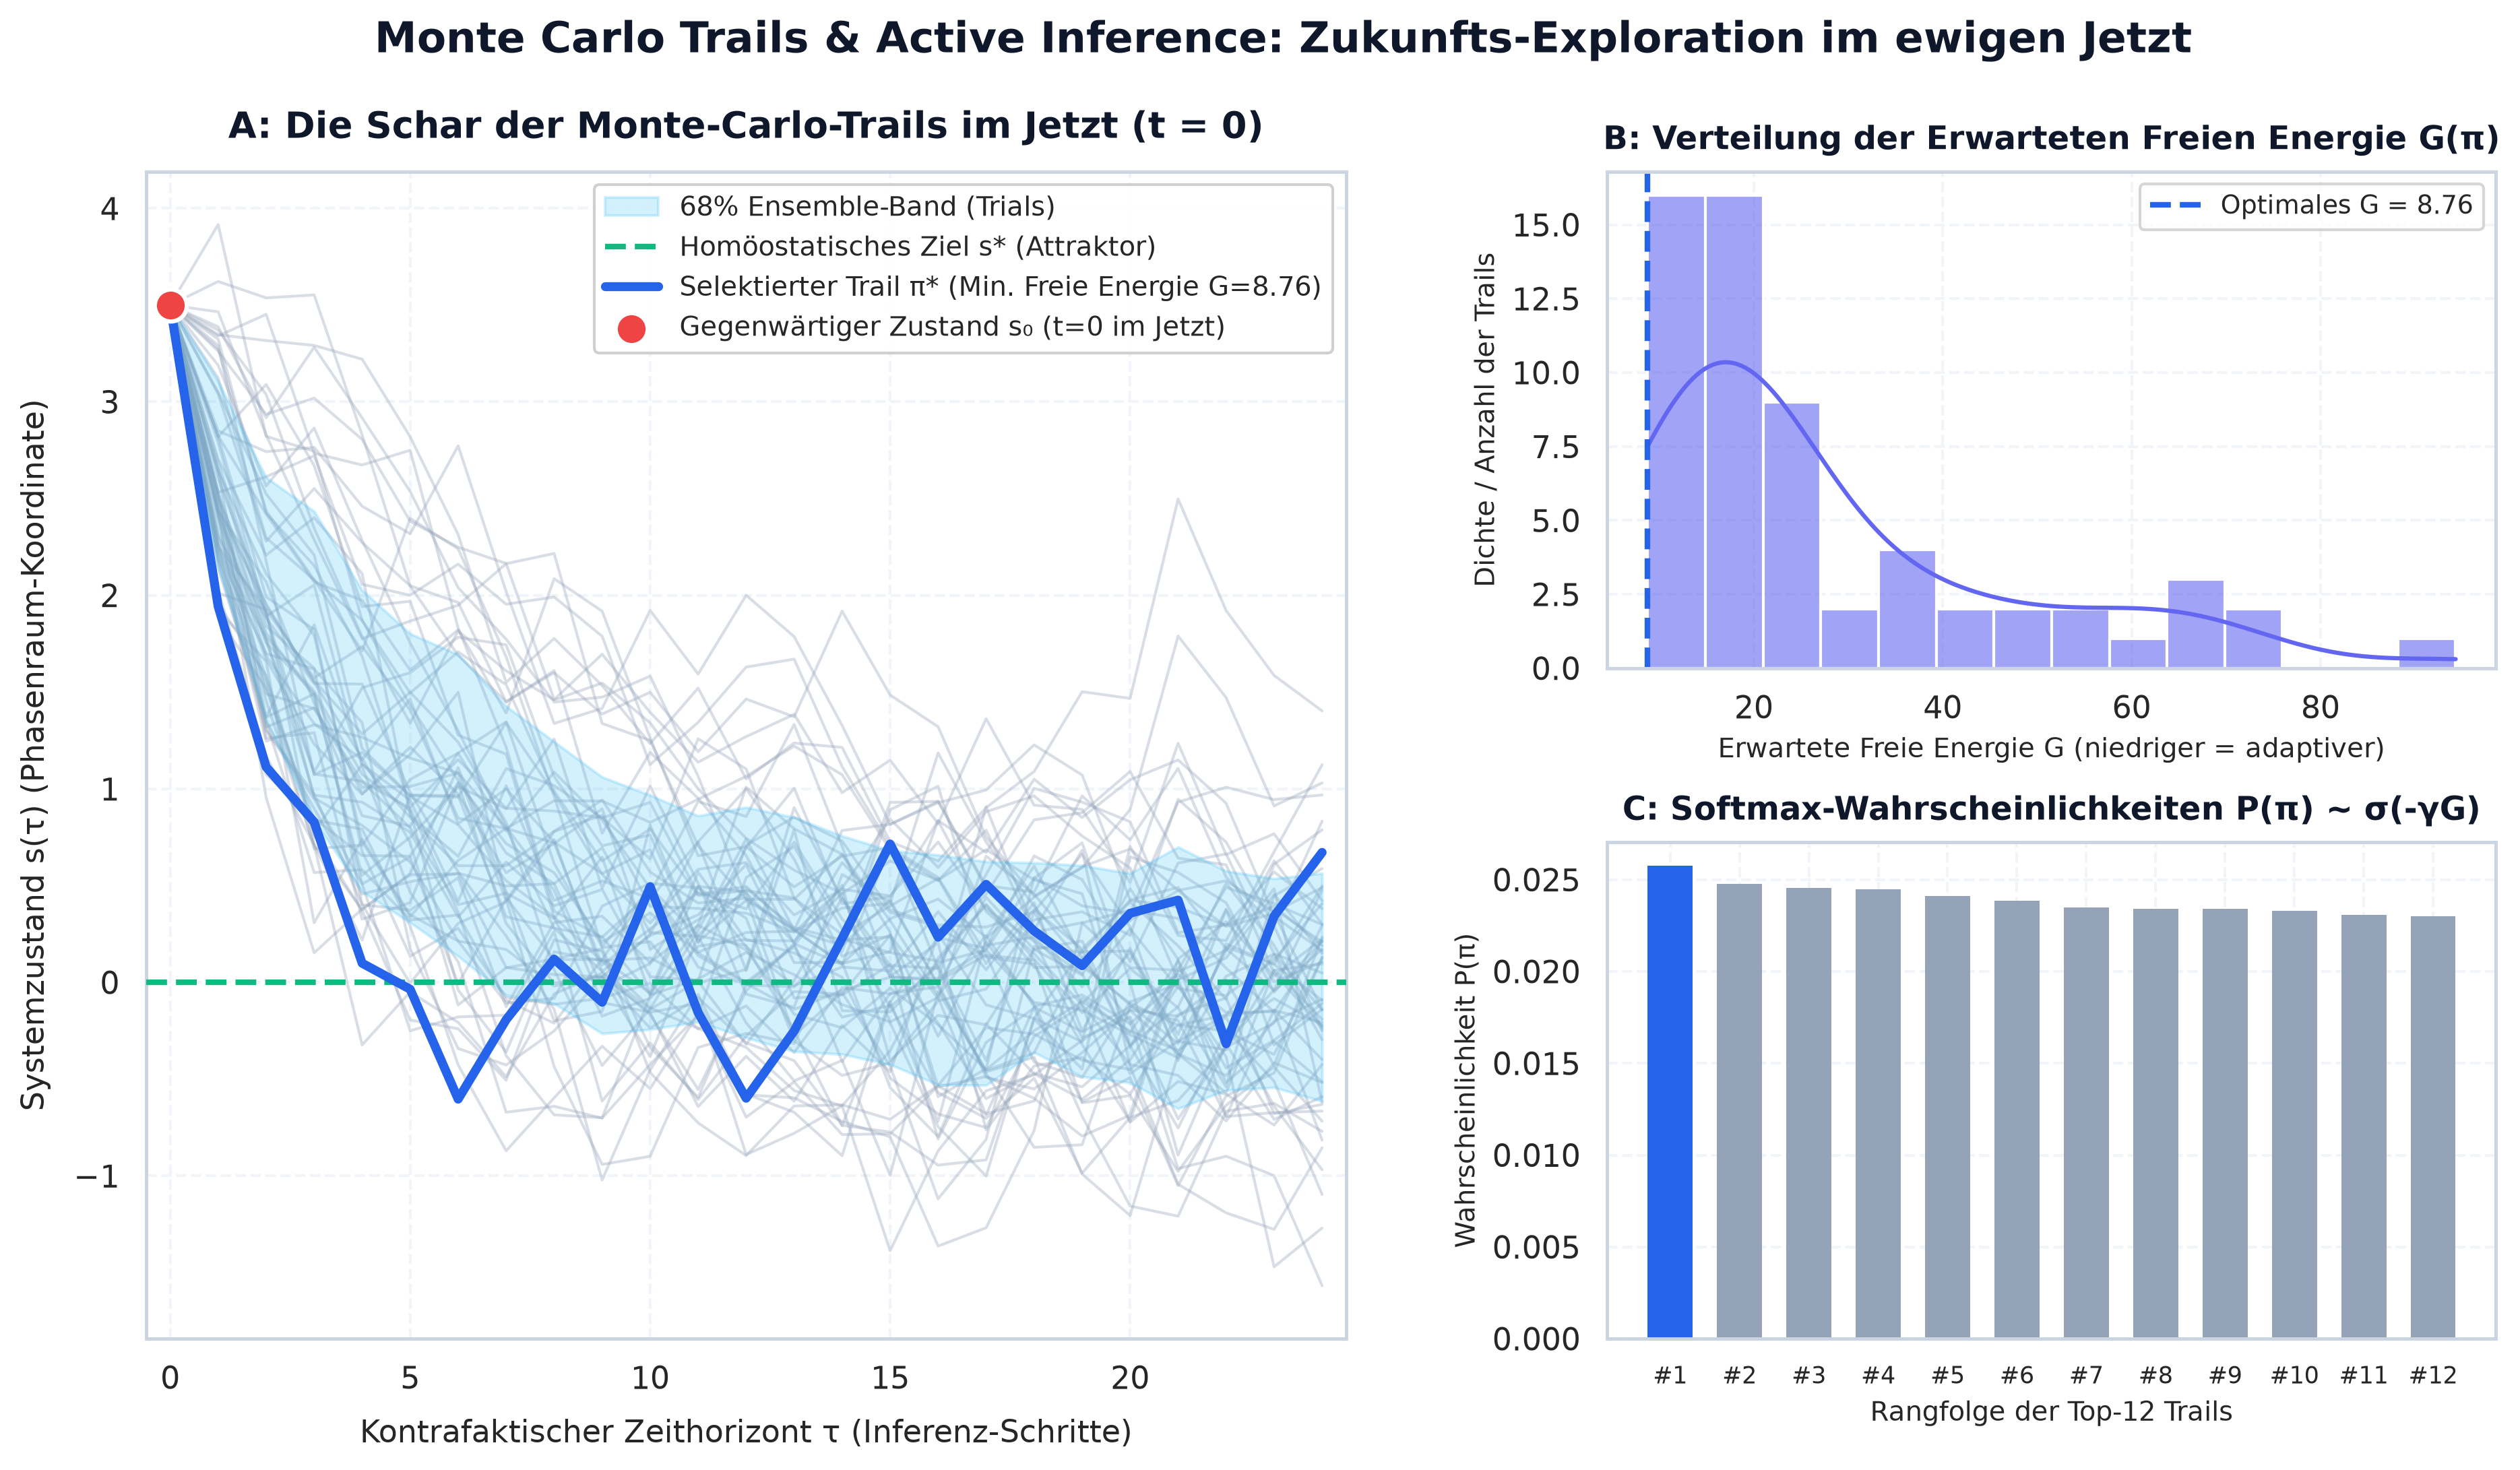

In [4]:
fig = plt.figure(figsize=(15, 7.5), dpi=300)
gs = fig.add_gridspec(2, 2, width_ratios=[1.35, 1], height_ratios=[1, 1], hspace=0.35, wspace=0.25)

time_steps = np.arange(HORIZON)

# --- PANEL A: DAS MONTE-CARLO-TRAIL-BÜNDEL ---
ax1 = fig.add_subplot(gs[:, 0])

# Zeichnen aller Einzel-Trails (Zukunfts-Fühler)
for i in range(N_TRAILS):
    ax1.plot(time_steps, trails[i, :], color='#94a3b8', alpha=0.35, linewidth=1.0, zorder=1)

# Mittelwert und Standardabweichungs-Band (Ensemble-Streuung)
mean_traj = np.mean(trails, axis=0)
std_traj = np.std(trails, axis=0)
ax1.fill_between(time_steps, mean_traj - std_traj, mean_traj + std_traj, color='#38bdf8', alpha=0.22, 
                 label='68% Ensemble-Band (Trials)', zorder=2)

# Homöostatisches Ziel (Attraktor)
ax1.axhline(TARGET_STATE, color='#10b981', linestyle='--', linewidth=2.0, 
            label='Homöostatisches Ziel s* (Attraktor)', zorder=3)

# Optimaler Trail pi*
ax1.plot(time_steps, best_trail, color='#2563eb', linewidth=3.2, 
         label=f'Selektierter Trail π* (Min. Freie Energie G={free_energies[best_trail_idx]:.2f})', zorder=4)

# Gegenwärtiger Zustand s0
ax1.scatter([0], [START_STATE], color='#ef4444', s=130, zorder=5, 
            label='Gegenwärtiger Zustand s₀ (t=0 im Jetzt)', edgecolors='white', linewidth=1.5)

ax1.set_title('A: Die Schar der Monte-Carlo-Trails im Jetzt (t = 0)', fontsize=13, fontweight='bold', pad=12, color='#0f172a')
ax1.set_xlabel('Kontrafaktischer Zeithorizont τ (Inferenz-Schritte)', fontsize=11, labelpad=8)
ax1.set_ylabel('Systemzustand s(τ) (Phasenraum-Koordinate)', fontsize=11, labelpad=8)
ax1.legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.92, fontsize=9.5)
ax1.set_xlim(-0.5, HORIZON - 0.5)

# --- PANEL B: VERTEILUNG DER ERWARTETEN FREIEN ENERGIE G ---
ax2 = fig.add_subplot(gs[0, 1])
sns.histplot(free_energies, kde=True, color='#6366f1', ax=ax2, bins=14, alpha=0.6, edgecolor='white')
ax2.axvline(free_energies[best_trail_idx], color='#2563eb', linestyle='--', linewidth=2.0, 
            label=f'Optimales G = {free_energies[best_trail_idx]:.2f}')
ax2.set_title('B: Verteilung der Erwarteten Freien Energie G(π)', fontsize=11.5, fontweight='bold', pad=8, color='#0f172a')
ax2.set_xlabel('Erwartete Freie Energie G (niedriger = adaptiver)', fontsize=9.5)
ax2.set_ylabel('Dichte / Anzahl der Trails', fontsize=9.5)
ax2.legend(loc='upper right', fontsize=9)

# --- PANEL C: SOFTMAX-WAHRSCHEINLICHKEITEN P(π) ---
ax3 = fig.add_subplot(gs[1, 1])
sorted_indices = np.argsort(free_energies)
top_n = 12
sorted_weights = weights[sorted_indices][:top_n]
bar_colors = ['#2563eb'] + ['#94a3b8'] * (top_n - 1)

ax3.bar(range(top_n), sorted_weights, color=bar_colors, edgecolor='none', width=0.65)
ax3.set_title('C: Softmax-Wahrscheinlichkeiten P(π) ~ σ(-γG)', fontsize=11.5, fontweight='bold', pad=8, color='#0f172a')
ax3.set_xlabel('Rangfolge der Top-12 Trails', fontsize=9.5)
ax3.set_ylabel('Wahrscheinlichkeit P(π)', fontsize=9.5)
ax3.set_xticks(range(top_n))
ax3.set_xticklabels([f'#{i+1}' for i in range(top_n)], fontsize=8.5)

fig.suptitle('Monte Carlo Trails & Active Inference: Zukunfts-Exploration im ewigen Jetzt', 
             fontsize=15, fontweight='bold', y=0.98, color='#0f172a')

# Speichern der Bild-Artefakte
img_path = '/home/thr/Documents/active-inference-phi-network/images/monte_carlo_trails_simulation.png'
vault_img = '/home/thr/Documents/ThRNotes/Alle_Braindumps_PDF/monte_carlo_trails_simulation.png'
os.makedirs(os.path.dirname(img_path), exist_ok=True)
os.makedirs(os.path.dirname(vault_img), exist_ok=True)

plt.savefig(img_path, dpi=300, bbox_inches='tight')
plt.savefig(vault_img, dpi=300, bbox_inches='tight')
print(f"✓ Abbildung erfolgreich gespeichert:")
print(f"  • {img_path}")
print(f"  • {vault_img}")

plt.show()


## 6. Sensitivitätsanalyse: Die fundamentale Rolle der Handlungspräzision $\gamma$

Die Präzision $\gamma$ fungiert in der Active-Inference-Formulierung als **inverse Temperatur** des Softmax-Operators:
$$P(\pi) = \frac{\exp(-\gamma G(\pi))}{\sum_{\pi'} \exp(-\gamma G(\pi'))}$$

Wir analysieren das Verhalten des Agenten unter drei verschiedenen kognitiven Regimes:
1. **Niedrige Präzision ($\gamma = 0.5$):** Hohe Verhaltensambivalenz, Exploration, diffuse Wahrscheinlichkeitsmasse.
2. **Mittlere Präzision ($\gamma = 2.5$):** Ausbalancierte Mischung aus Exploration und Zielstrebigkeit.
3. **Hohe Präzision ($\gamma = 8.0$):** Quasi-deterministische Fokussierung auf den Best-Trail (hohe Entschlossenheit / Handlungsdruck).

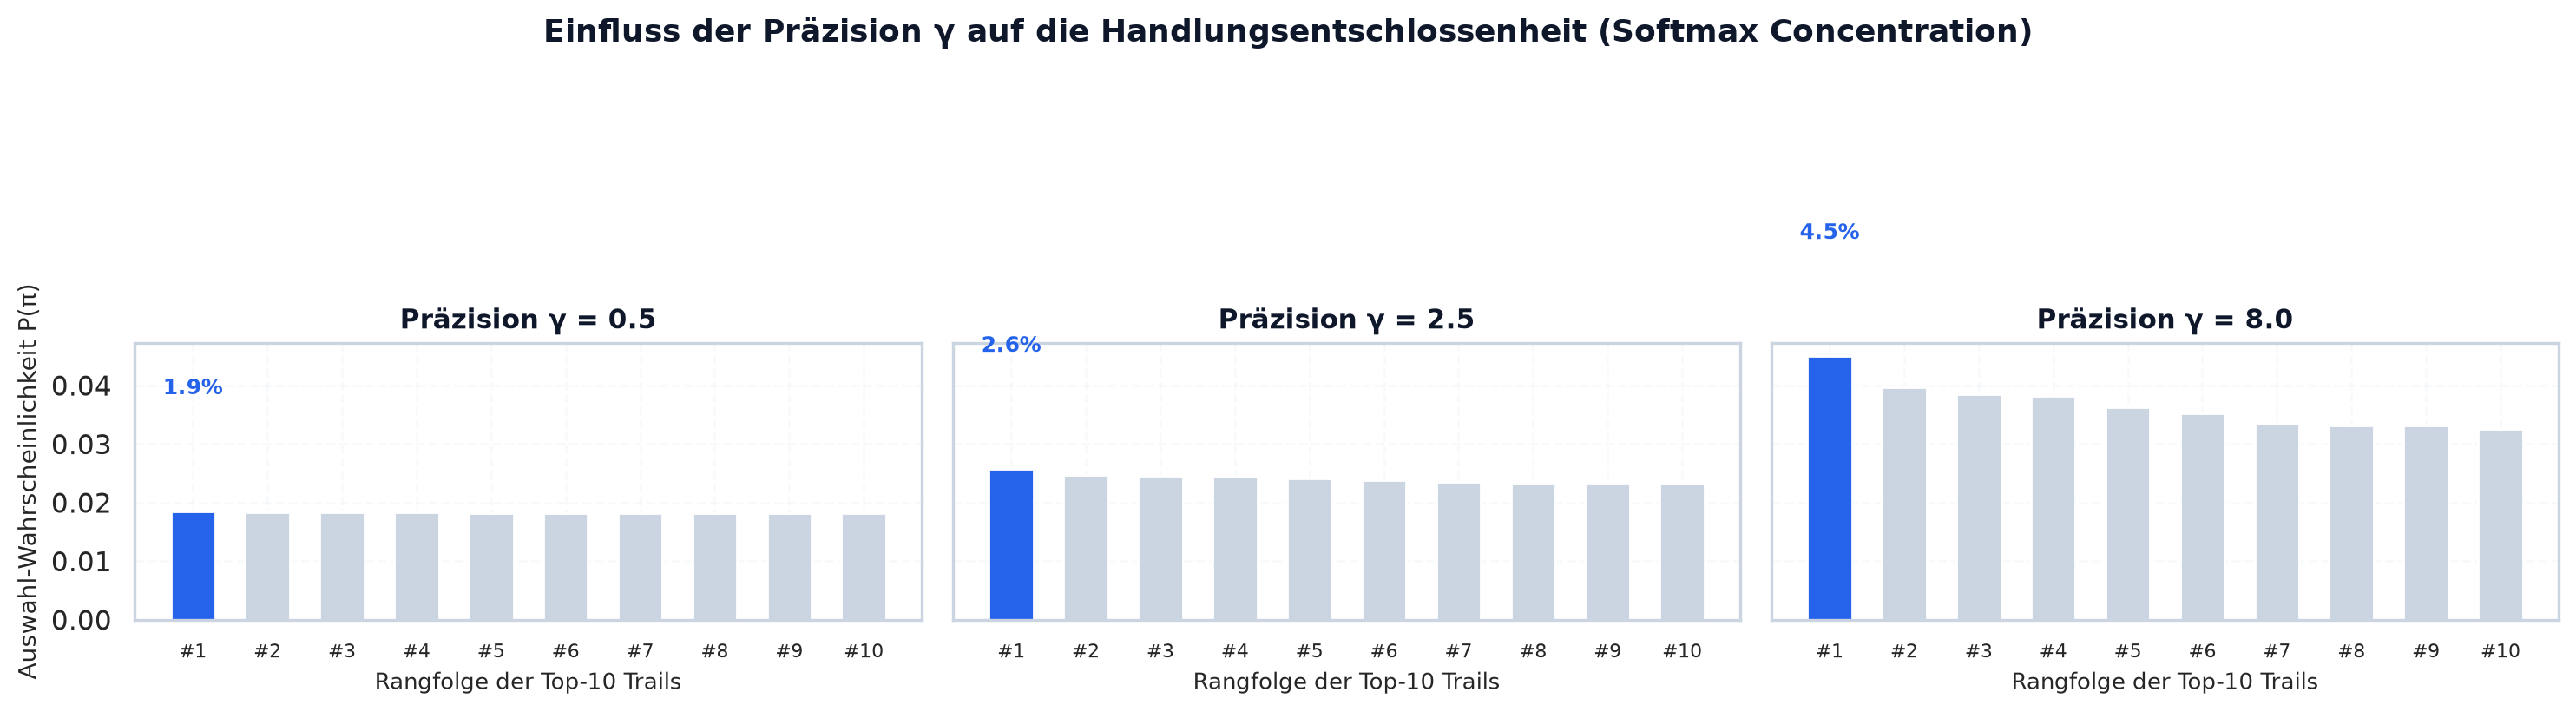

In [5]:
gamma_values = [0.5, 2.5, 8.0]
fig, axes = plt.subplots(1, 3, figsize=(15, 4), dpi=200, sharey=True)

for ax, g in zip(axes, gamma_values):
    # Softmax mit modifiziertem Gamma
    w = np.exp(-g * norm_g)
    w /= np.sum(w)
    sorted_w = w[sorted_indices][:10]
    
    bars = ax.bar(range(10), sorted_w, color=['#2563eb'] + ['#cbd5e1']*9, width=0.6)
    ax.set_title(f'Präzision γ = {g}', fontsize=11, fontweight='bold', color='#0f172a')
    ax.set_xlabel('Rangfolge der Top-10 Trails', fontsize=9.5)
    ax.set_xticks(range(10))
    ax.set_xticklabels([f'#{i+1}' for i in range(10)], fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.5)
    
    # Spitzen-Wahrscheinlichkeit annotieren
    ax.text(0, sorted_w[0] + 0.02, f'{sorted_w[0]*100:.1f}%', ha='center', fontweight='bold', color='#2563eb', fontsize=9)

axes[0].set_ylabel('Auswahl-Wahrscheinlichkeit P(π)', fontsize=10)
fig.suptitle('Einfluss der Präzision γ auf die Handlungsentschlossenheit (Softmax Concentration)', 
             fontsize=13, fontweight='bold', y=1.02, color='#0f172a')
plt.tight_layout()
plt.show()


## 7. Ontologische Synthese: Buch 2 (*Vom Anfang bis zum Ende*)

Die Ergebnisse dieser Monte-Carlo-Simulation liefern das mathematisch-physikalische Fundament für zentrale Thesen von **Buch 2**:

### 1. Radikale Gegenwart vs. Scheinhaftigkeit der Zeit
* Es gibt im Kosmos keinen Behälter namens „Zeit“, der von der Vergangenheit in die Zukunft fließt.
* Die einzige ontologische Realität ist der infinitesimale Phasenraum-Zustand des Universums im **Jetzt ($t = 0$)**.
* Zukunft ist kein Ort, an den wir reisen, sondern die **virtuelle Interferenzmenge von Monte-Carlo-Trails**, die ein autopoietisches Teilsystem (Organismus, Geist) intern aufspannt, um seine dissipative Entropie zu minimieren.

### 2. Agency & Conatus (Spinoza & Friston)
* Der von Spinoza postulierte *Conatus* (das fundamentale Streben jedes Wesens, in seinem Sein zu verharren) ist im Active-Inference-Paradigma exakt die **Minimierung der Erwarteten Freien Energie $G(\pi)$**.
* Ohne kontrafaktische Zukunfts-Trails ($H = 0$) ist ein System rein reaktiv und der Umwelt ausgeliefert. Erst die temporale Tiefe ($H > 1$) konstituiert **Agency** und echtes Selbstsein.

### 3. Stoische Gelassenheit (*Amor Fati*)
* Da alle Trails lediglich mentale Projektionen im Jetzt sind, verliert die Zukunft ihren bedrohlichen Charakter.
* Die optimale Haltung besteht darin, im gegenwärtigen Moment den Pfad mit minimaler Freier Energie zu wählen ($u_0^* = \pi^*_0$), das Ergebnis aber gelassen der stochastischen Natur des Kosmos zu überlassen.

---

## Tool-Attribution & Kolophon

> **Kolophon & Autorenangabe:**  
> **Konzeption & Theorie:** Thomas Riebl (Luxemburg)  
> **Framework:** *The Conative-Integrative Framework (CIF)* & *Buch 2: Vom Anfang bis zum Ende*  
> **Software & Visualisierung:** Entwickelt mit Python 3.14, Seaborn, Matplotlib, NumPy und dem Antigravity Agentic Framework (September 2026).  
> **Repository:** [`https://github.com/Thriebl/active-inference-phi-network`](https://github.com/Thriebl/active-inference-phi-network)  
> **Vault-Archiv:** `ThRNotes/03-professional/braindumps/`
